 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.

In [65]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [89]:
df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)

total_by_institution = df.groupby("Institution Name")["Foreign Gift Amount"].sum().reset_index()

mean = total_by_institution["Foreign Gift Amount"].mean()
median = total_by_institution["Foreign Gift Amount"].median()

print(f"{mean}, {median}")

52202878.974842764, 6486791.5


In [90]:
va_df = df[df["State"] == "VA"]

va_mean = va_df["Foreign Gift Amount"].mean()
va_median = va_df["Foreign Gift Amount"].median()

print(f"{va_mean}, {va_median}")

657414.3321917808, 93868.0


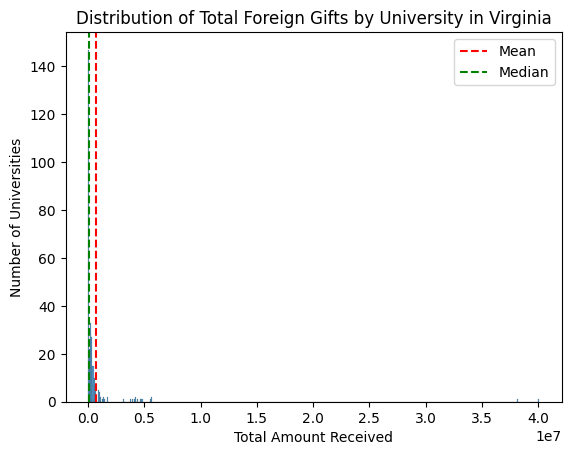

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=va_df, x="Foreign Gift Amount")

plt.axvline(va_mean, linestyle="--", label="Mean", color="red")
plt.axvline(va_median, linestyle="--", label="Median", color="green")

plt.xlabel("Total Amount Received")
plt.ylabel("Number of Universities")
plt.title("Distribution of Total Foreign Gifts by University in Virginia")
plt.legend()

plt.show()

In [42]:
uva_df = df[df["Institution Name"] == "University of Virginia"]
uva_df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [43]:
print(uva_df["Foreign Gift Amount"].sum())

22189238


In [59]:
total_by_country = uva_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).reset_index(name="Total Gift Amount")
total_by_country

,Country of Giftor,Total Gift Amount
0,BANGLADESH,4228589
1,SWEDEN,4007552
2,TANZANIA,2776447
3,SWITZERLAND,2000000
4,ENGLAND,1950666
5,GUERNSEY,1500000
6,FINLAND,1008384
7,BERMUDA,900000
8,KOREA,862787
9,SINGAPORE,805000


In [57]:
count_by_country = uva_df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False).reset_index(name="Total Gift Count")
count_by_country

,Country of Giftor,Total Gift Count
0,ENGLAND,31
1,ISRAEL,12
2,BANGLADESH,10
3,SWEDEN,10
4,FINLAND,7
5,KOREA,6
6,FRANCE,5
7,THE NETHERLANDS,4
8,GUERNSEY,3
9,TANZANIA,3


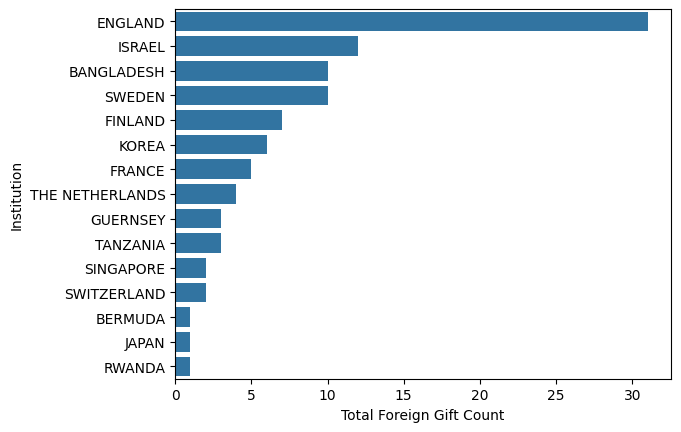

In [60]:
sns.barplot(data=count_by_country, x="Total Gift Count", y="Country of Giftor")

plt.title("")
plt.xlabel("Total Foreign Gift Count")
plt.ylabel("Institution")
plt.show()

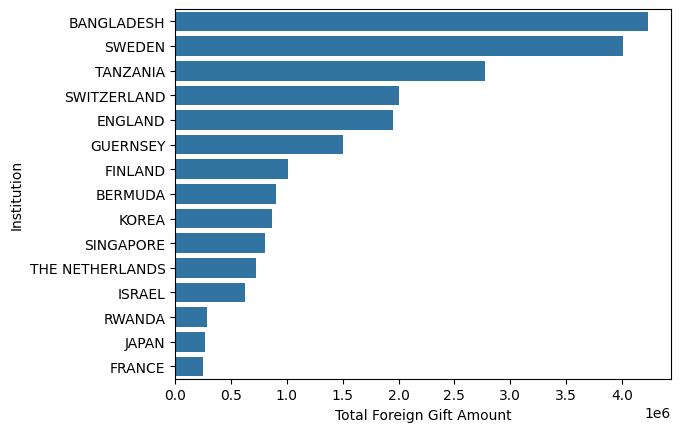

In [61]:
sns.barplot(data=total_by_country, x="Total Gift Amount", y="Country of Giftor")

plt.title("")
plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Institution")
plt.show()

In [81]:
peer_institutions = ["University of Virginia", "University of Michigan - Ann Arbor", "University of North Carolina - Chapel Hill"]

peer_df = df[df["Institution Name"].isin(peer_institutions)]

In [84]:
peer_institutions_va = ["University of Virginia", "College of William & Mary", "Virginia Polytechnic Institute & State University"]

va_df = df[df["Institution Name"].isin(peer_institutions_va)]

In [85]:
#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'

flows = (
    peer_df.groupby([giftor, recipi])[flow]
    .sum()
    .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

In [86]:
va_flows = (
    va_df.groupby([giftor, recipi])[flow]
    .sum()
    .reset_index()
)

labels = (
    va_flows[giftor].tolist()
    + va_flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=va_flows[giftor]
                        .map(labels.index),
            target=va_flows[recipi]
                        .map(labels.index),
            value=va_flows[flow]
        )
    )
)

fig.show()